In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exercise 02.1

In [3]:
integral=pd.read_csv('data/cosinteg_M1000000.csv')
df_is=pd.read_csv('data/cosinteg_M1000000_is.csv')


It's clearly visible that using the first order taylor expansion in $x=1$ of the cos function the convergence is faster with a minor variance


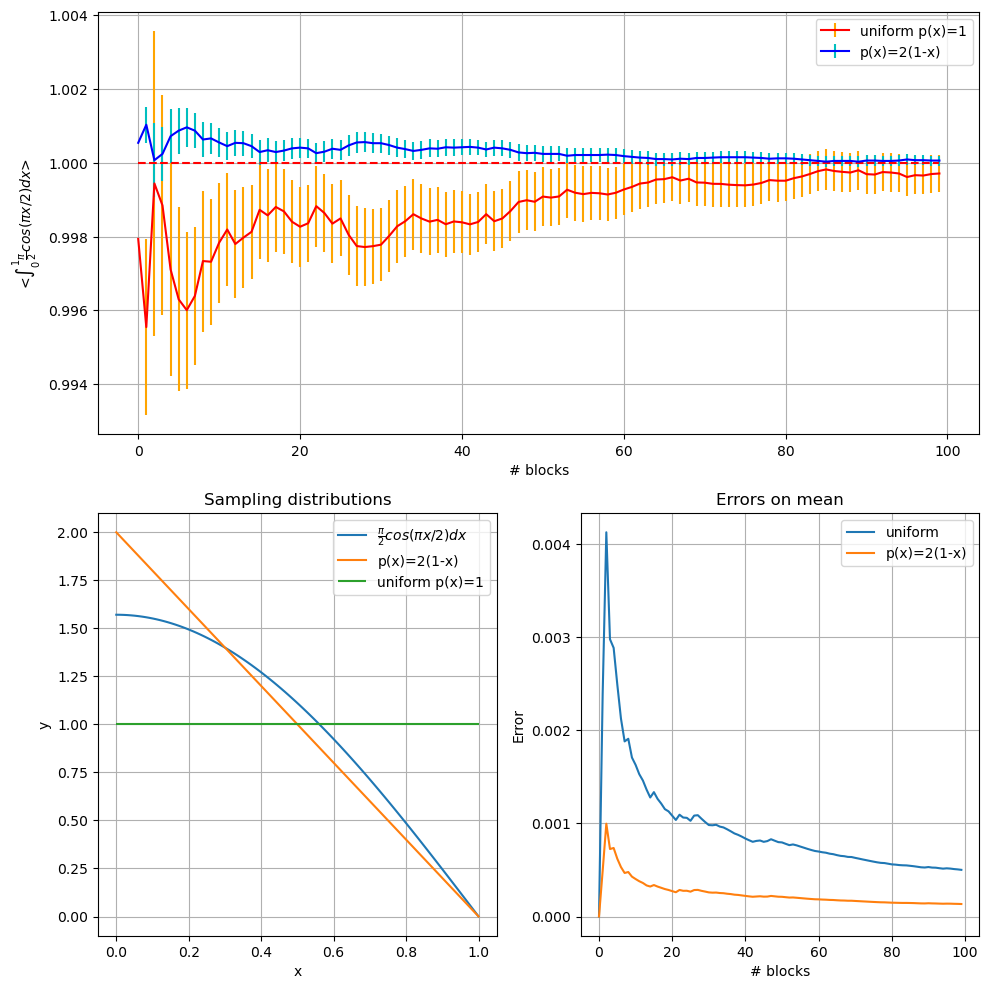

In [34]:
#fig, ax = plt.subplots(1, 2, width_ratios=[2, 1],figsize=(10,5))
fig = plt.figure(figsize=(10,10))
ax0 = plt.subplot(2,1,1)
ax0.errorbar(integral.index, integral.avg, color='r', ecolor='orange', yerr=integral.err, label='uniform p(x)=1')
ax0.errorbar(df_is.index, df_is.avg, yerr=df_is.err, label='p(x)=2(1-x)', color='b', ecolor='c')
ax0.hlines(1, 0, df_is.index[-1], linestyles='--', colors='r')
ax0.legend()
ax0.set_ylabel(r'<$\int_0^1 \frac{\pi}{2} cos(\pi x/2 )dx$>')
ax0.set_xlabel('# blocks')
ax0.grid(True)

ax1 = plt.subplot(2,2,3)
ax1.set_title('Sampling distributions')

x = np.linspace(0,1,100)

ax1.plot(x, 0.5*np.pi*np.cos(np.pi*x*0.5),
    label=r'$\frac{\pi}{2} cos(\pi x/2 )dx$'
    )
ax1.plot(x, 2*(1-x), label='p(x)=2(1-x)')
ax1.hlines(1, 0, 1, color='C2', label='uniform p(x)=1')
ax1.grid()
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()

ax2 = plt.subplot(2,2,4)
ax2.set_title('Errors on mean')
ax2.plot(integral.index, integral['err'], label='uniform')
ax2.plot(df_is.index, df_is['err'], label = 'p(x)=2(1-x)')
ax2.set_xlabel('# blocks')
ax2.set_ylabel('Error')
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()


# Exercise 02.2: Random Walk


## Code implementation
I implemented 2 classes [Random Walk](random_walk.h) (lattice and continuous) 

```C++
class RW_lattice
{
	public:
		//constructor
		RW_lattice(); //default constructor
		RW_lattice(double a, int* seed);
		
		//destructor
		~RW_lattice(){};
		
		//methods
		vector<double> get_pos () const{return pos;};
		int get_nstep() const {return step;};
		//reset the position and number of steps
		void reset_rw(); 
		
		//make a step in random direction and 
		// verse on the lattice
		void make_step();
		
	protected:
		double m_a;
		vector<double> pos=vector <double>(3, 0.0);
		
		Random rnd;
		int step;
		
		
		double verse_increment();
		vector<double> dir_increment(
			double p_x=1/3., 
			double p_y=1/3.,
			double p_z=1/3.
		);
};


```

The continuous version has an identical header, the difference are in the implementation inside the step functions.

Both of classes have:
```C++

void make_step()
{
	//select direction x | y | z
	vector <double> stepv = dir_increment();		
		
	// select verse Rx | Lx
	double verse=verse_increment();	// return sign *m_a
	
	// generate step of lenght a and update position and step number
	for(int i=0; i<3; ++i)
	{
		pos[i]+=stepv[i]*verse;
	}
	
	step+=1;
}
```

But for the lattice only step along the 3 axis direction are avaiable
```C++
//return copy but 3dim not heavy
vector<double> RW_lattice::dir_increment(double p_x, double p_y, double p_z)
{
	double r = rnd.Rannyu();
	if(r<p_x)
		return vector<double> {1., 0., 0.};
	else if(r<p_x+p_y)
		return vector<double> {0., 1., 0.};
	else
		return vector<double> {0., 0., 1.};
}

```

While the contiuous version make sampling on the sphere:

```C++
//return copy but 3dim not heavy
vector<double> RW_continuous::dir_increment(double p_x, double p_y, double p_z)
{
	double phi=rnd.Rannyu();
	double r = rnd.Rannyu();
	double theta=acos(1-2*r);

	return vector<double> {
		sin(theta)*cos(phi),
		sin(theta)*sin(phi),
		cos(theta)
	};
}

```


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

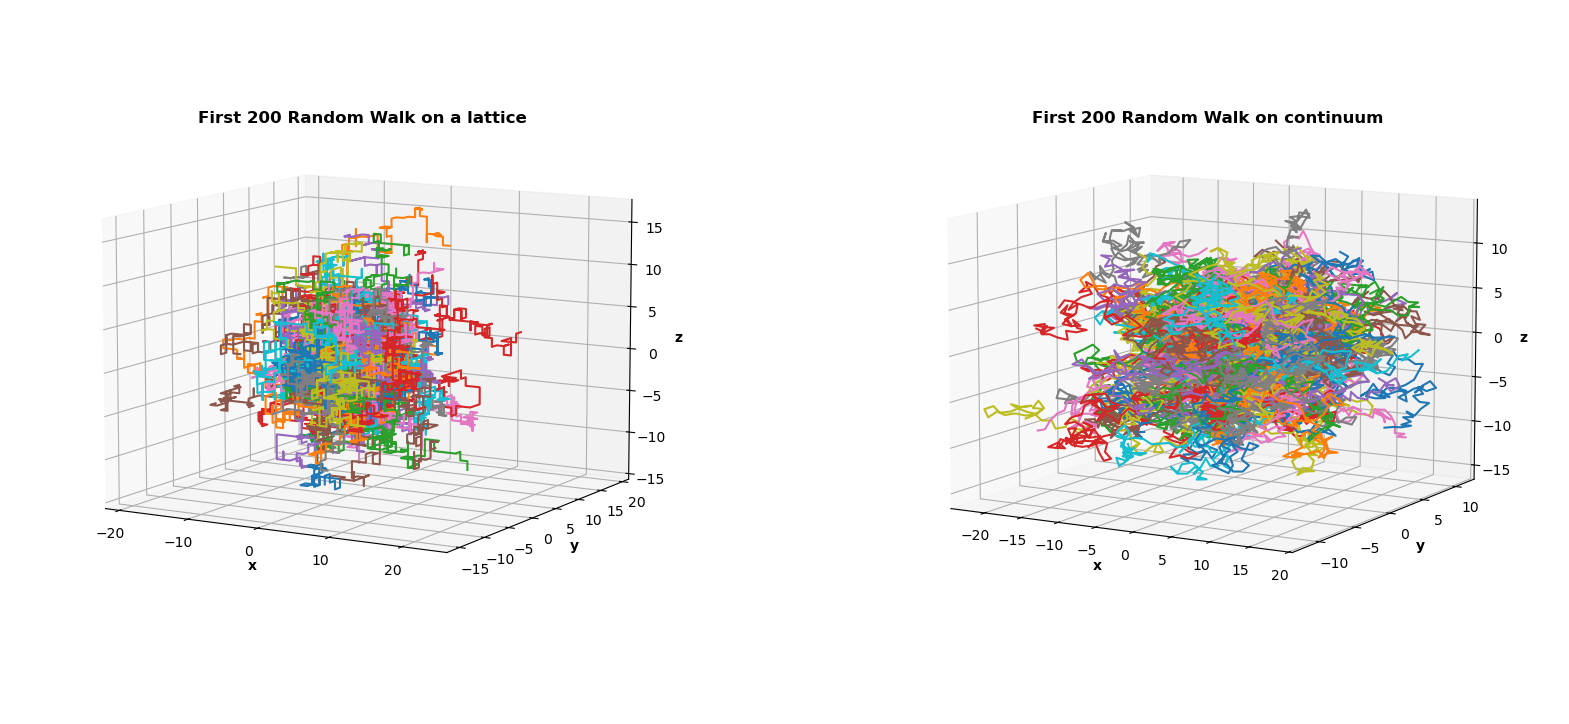

In [42]:
df=pd.read_csv('data/RW_lattice.csv')
crw=pd.read_csv('data/RW_continuous_lattice.csv')

fig=plt.figure(
    figsize=(20,10)
)
ax=fig.add_subplot(1, 2, 1, projection='3d')
ax.set_box_aspect(None, zoom=0.85)
for run in df['#rw'].unique()[:200]:
    dfr=df.loc[df['#rw']==run]
    ax.plot(dfr.x, dfr.y, dfr.z, '-', label=f'run={run}')
#plt.legend()
ax.set_xlabel('x', fontweight='bold')
ax.set_ylabel('y', fontweight='bold')
ax.set_zlabel('z', fontweight='bold')
#ax.ticks_params(fontweight='bold')
ax.view_init(elev=10)
ax.set_title('First 200 Random Walk on a lattice', fontweight='bold', y=0.9)

ax=fig.add_subplot(1,2,2, projection='3d')
ax.set_box_aspect(None, zoom=0.85)
for run in crw['#rw'].unique()[:200]:
    dfr=crw.loc[crw['#rw']==run]
    ax.plot(dfr.x, dfr.y, dfr.z, '-', label=f'run={run}')
#plt.legend()
ax.set_xlabel('x', fontweight='bold')
ax.set_ylabel('y', fontweight='bold')
ax.set_zlabel('z', fontweight='bold')
#ax.ticks_params(fontweight='bold')
ax.view_init(elev=10)
ax.set_title('First 200 Random Walk on continuum', fontweight='bold', y=0.9)
plt.show()
plt.show()


To compute the mean value of the explored distance of the Random Walk, $10^4$ relization of the RW were computed and distributed along 100 blocks.

On those blocks was calculated the progressive average for every step value storing the results of the progressive averages in the rows of a matrix with dimensions nstep x nblock



## Data Visualization
### Lattice RW

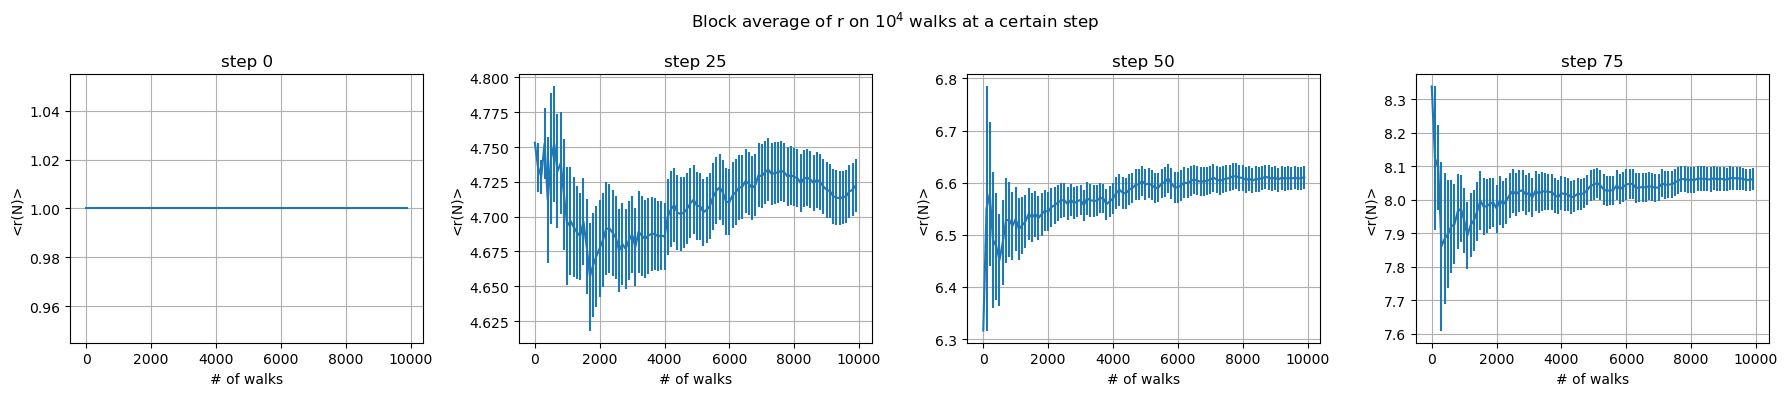

In [44]:
dfrn_lat=pd.read_csv('data/RW_rn.csv')

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Block average of r on $10^4$ walks at a certain step')
for N in dfrn_lat.N.unique()[::25]:
    dfn=dfrn_lat.loc[dfrn_lat.N==N]
    ax[N//25].set_title(f'step {N}')
    ax[N//25].errorbar(100*dfn.block, dfn.rN, yerr=dfn.err)
    ax[N//25].set_xlabel('# of walks')
    ax[N//25].set_ylabel('<r(N)>')
    ax[N//25].grid()
plt.tight_layout()
plt.show()

Taking the last block of every step the underlying figure show the diffusive behavior of the Random Walks $k\sqrt{N}$

In [38]:
from scipy.optimize import curve_fit

def diffuse(N, k:float):
    return k*np.sqrt(N)

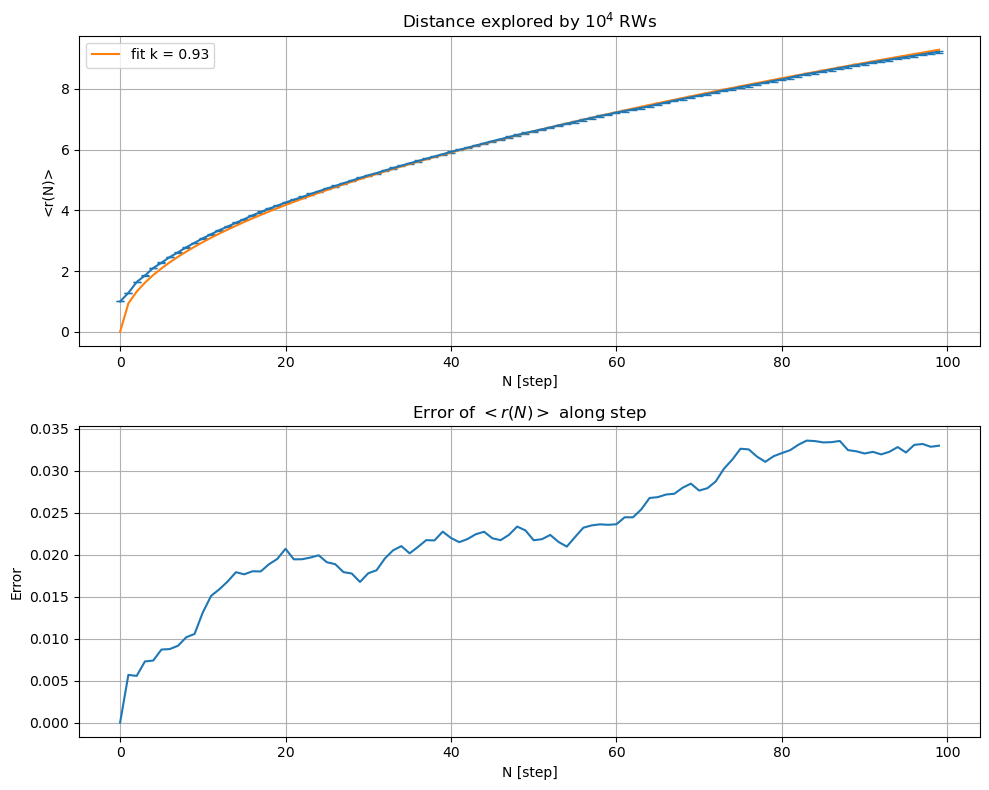

In [39]:
diff_m=dfrn_lat.loc[dfrn_lat.block==99].reset_index(drop=True) # last block values

# fit parameters
popt, pcov = curve_fit(diffuse, diff_m.N, diff_m.rN)

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].errorbar(diff_m.N, diff_m.rN, yerr=diff_m.err, capsize=3)
ax[0].plot(diff_m.N, diffuse(diff_m.N, popt[0]), label=f'fit k = {"%.2f" % popt[0]}')
ax[0].grid(True)
ax[0].set_xlabel('N [step]')
ax[0].set_ylabel('<r(N)>')
ax[0].set_title('Distance explored by $10^4$ RWs')
ax[0].legend()


ax[1].set_title('Error of $ < r(N) > $ along step')
ax[1].plot(diff_m.err)
ax[1].set_xlabel('N [step]')
ax[1].set_ylabel('Error')
ax[1].grid()

plt.tight_layout()
plt.show()

### Continuous RW

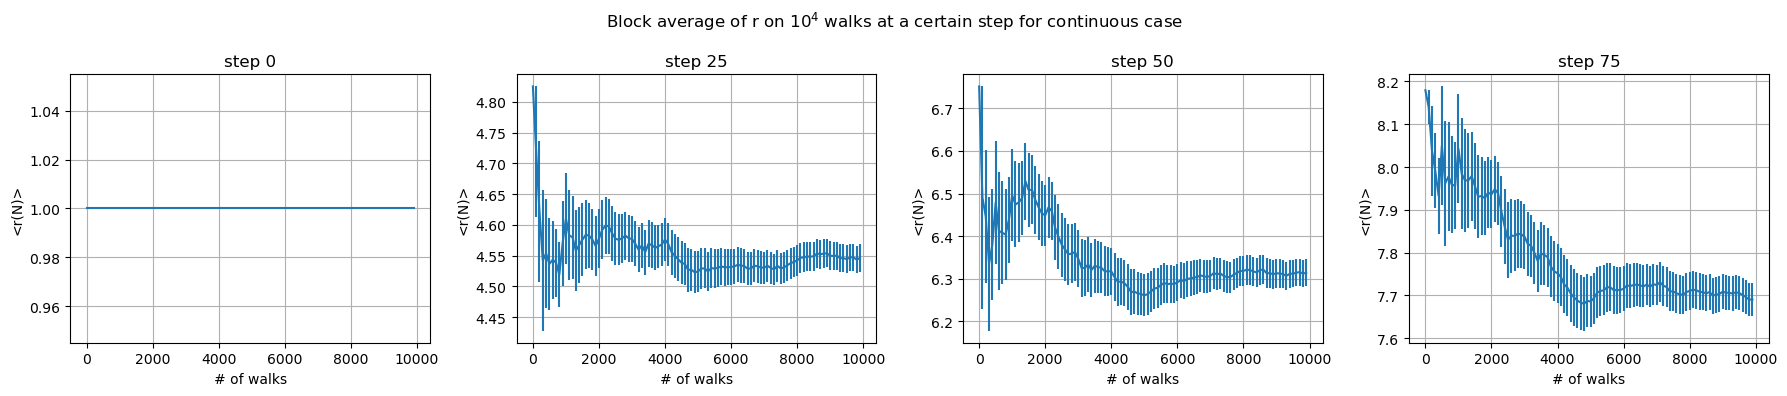

In [45]:
dfrn=pd.read_csv('data/RW_continuous_rn.csv')

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Block average of r on $10^4$ walks at a certain step for continuous case')
for N in dfrn.N.unique()[::25]:
    dfn=dfrn.loc[dfrn.N==N]
    ax[N//25].set_title(f'step {N}')
    ax[N//25].errorbar(100*dfn.block, dfn.rN, yerr=dfn.err)
    ax[N//25].set_xlabel('# of walks')
    ax[N//25].set_ylabel('<r(N)>')
    ax[N//25].grid()
plt.tight_layout()
plt.show()

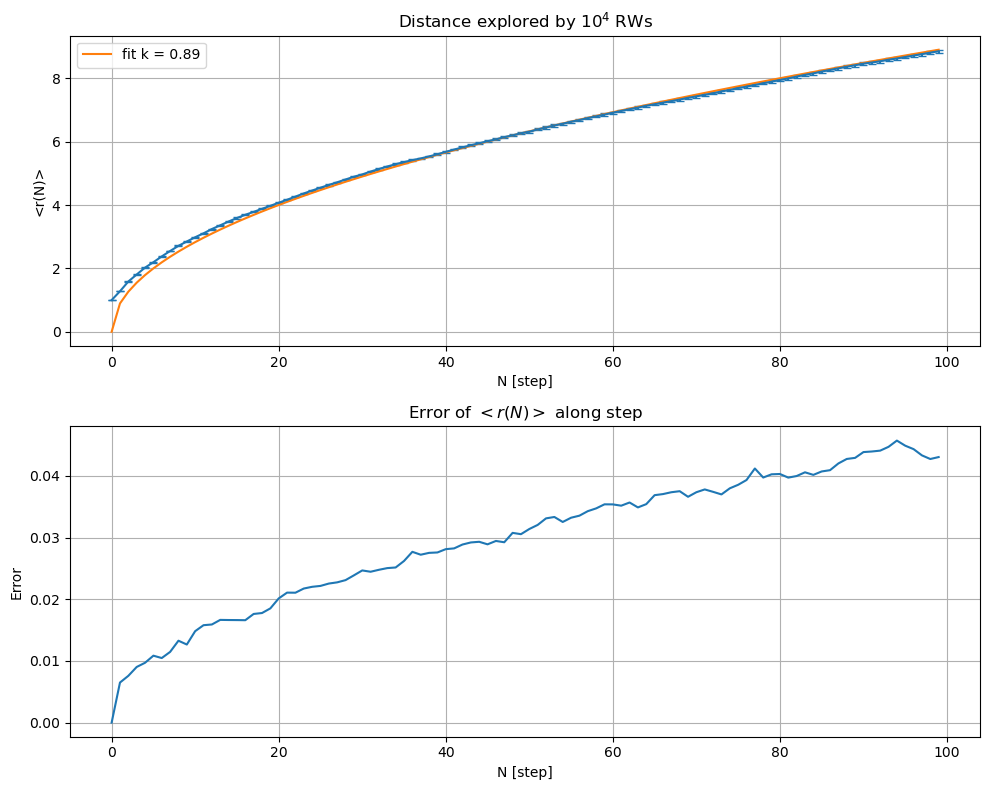

In [41]:
df=dfrn.loc[dfrn.block==99].reset_index(drop=True)


# fit parameters
popt, pcov = curve_fit(diffuse, df.N, df.rN)

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].errorbar(df.N, df.rN, yerr=df.err, capsize=3)
ax[0].plot(diff_m.N, diffuse(diff_m.N, popt[0]), label=f'fit k = {"%.2f" % popt[0]}')
ax[0].grid(True)
ax[0].set_xlabel('N [step]')
ax[0].set_ylabel('<r(N)>')
ax[0].set_title('Distance explored by $10^4$ RWs')
ax[0].legend()


ax[1].plot(df.err)
ax[1].set_xlabel('N [step]')
ax[1].set_ylabel('Error')
ax[1].set_title('Error of $ < r(N) > $ along step')
ax[1].grid()

plt.tight_layout()
plt.show()

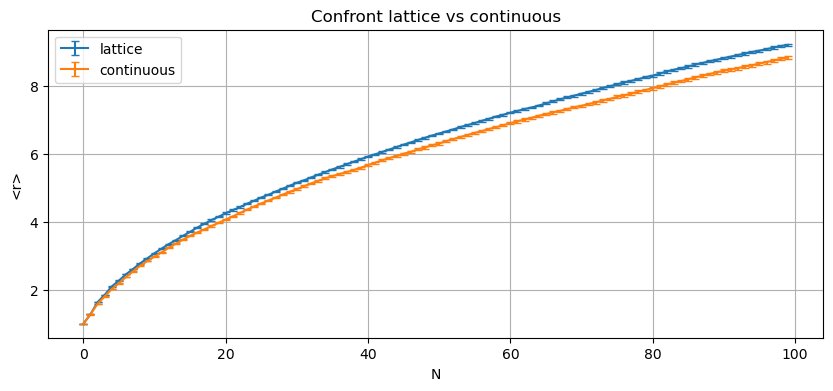

In [42]:
plt.figure(figsize=(10, 4))
plt.title('Confront lattice vs continuous')
plt.errorbar(diff_m.N, diff_m.rN, yerr=diff_m.err,capsize=3, label='lattice')
plt.errorbar(df.N, df.rN, yerr=df.err, capsize=3, label='continuous')
plt.legend()
plt.xlabel('N')
plt.ylabel('<r>')
plt.grid()
plt.show()

It's visible how the lattice RW seem to explore the space faster than the continuous version 